# Can We See It Coming?
## Predicting Graduation Outcomes of Nigerian Engineering Students from Early Academic Performance

**Final Project — Kujenga Course**

---

### A Personal Note

I am a final-year engineering student in Nigeria. Over the past few years, I have watched the people around me — coursemates, friends, juniors — go through the same degree programme I am in. Some thrived. Some struggled quietly. A few disappeared before final year, and nobody seemed to see it coming until the results came out at the end.

That is the question that started this project for me: **was the outcome already visible in their early grades, and did anyone bother to look?**

If we could see the warning signs by the end of second year — when there is still time to act, still time to support, still time to change the trajectory — we might be able to help students before failure becomes irreversible.

This project uses real academic records from 1,841 engineering undergraduates at a Nigerian university to ask one simple question: **using only what is knowable by the end of Year 2, can we predict how a student will graduate?**


## 1. Why This Matters: The Nigerian Engineering Education Crisis

Before diving into the data, it is worth grounding this question in the broader reality of Nigerian higher education.

### The numbers paint a difficult picture:

- The **tertiary dropout rate in Nigerian universities is approximately 20%** (2020 estimates), with some estimates placing it as high as **22%**, largely due to financial difficulties and academic struggle.
- The **graduate unemployment rate in Nigeria reached 33% in 2023**, with many engineering graduates forced to apply for jobs in banking, teaching, sales, and administration completely outside their field of training simply to survive.
- A National Information Technology Development Agency (NITDA) report found that **85% of Nigerian graduates lack basic digital skills** — a striking finding given that many of these are STEM and engineering graduates.
- Engineering programmes in Nigeria typically run for **5 years** rather than the standard 4-year arts/sciences degree, meaning the cost of dropping out late, or graduating with a poor class, is even higher.

### What this means for our research question:

When a Nigerian engineering student fails or drops out, they do not just lose time — they lose five years of their life, significant family financial investment, and often their confidence in continuing technical careers. Identifying at-risk students early enough to intervene is not an academic exercise. It is a question with real human stakes.

The original Odukoya et al. (2018) paper that produced this dataset asked whether **admission variables** (entry age, UTME score, SSCE aggregate, post-UTME screening) predicted final CGPA. Their finding was sobering: even SSCE aggregate, the strongest predictor, showed only moderate correlation with graduation outcomes.

**Our project asks a different question:** what about the GPA students actually earn in their first two years at university? Is *that* a stronger early-warning signal than admission scores alone?

---

### Sources for the statistics above:
- *Nigeria Education Statistics* — Tertiary dropout rate ~20% (2020).
- *ZipDo Education Reports* (2025) — University dropout rate ~22%, mainly financial.
- *Nigeria Education Market Data Report* (2026) — Graduate unemployment 33% in 2023.
- *NITDA via Veriv Africa* — 85% of Nigerian graduates lack digital skills.


## 2. Research Question and Hypothesis

### Main Question
> **By the end of Year 2, can we predict the graduation outcome of a Nigerian engineering undergraduate using only their early academic performance?**

### Sub-questions
1. How strongly does Year 1 GPA alone predict Final CGPA?
2. Does adding Year 2 GPA improve the prediction?
3. Is there a statistically significant difference in early GPA between students who graduate strongly (First Class / Second Class Upper) and those who graduate weakly (Second Class Lower / Third Class)?
4. Are some engineering departments more "predictable" from early performance than others?

### Hypotheses
- **H1 (regression):** Early GPA (Years 1 and 2) is positively and significantly associated with Final CGPA.
- **H2 (t-test):** Students who graduate with strong outcomes have significantly higher early GPAs than students who graduate with weak outcomes.
- **H3 (combined):** Combining Year 1 and Year 2 GPA produces a stronger predictor than either year alone.

### Methods (mapped to Kujenga course concepts)
- **Week 1 — Linear Regression:** Fit best-fit lines from Year 1 GPA, Year 2 GPA, and combined Year 1+2 GPA to Final CGPA. Compare R² values.
- **Week 3 — Two-Sample t-test:** Test whether Year 1 and Year 2 GPA differ significantly between strong and weak graduating groups.


## 3. Dataset Description

### Source
The dataset comes from a peer-reviewed publication:

> Odukoya, J. A., Popoola, S. I., Atayero, A. A., Omole, D. O., Badejo, J. A., John, T. M., & Olowo, O. O. (2018). *Learning analytics: Dataset for empirical evaluation of entry requirements into engineering undergraduate programs in a Nigerian university.* **Data in Brief, 17**, 998–1014. https://doi.org/10.1016/j.dib.2018.02.025

A companion dataset of academic records for engineering undergraduates at **Covenant University, Ota, Nigeria** is the file we use here.

### Coverage
- **University:** Covenant University, Ota, Nigeria
- **Sample size:** 1,841 engineering undergraduates
- **Admission years:** 2002/2003 through 2009/2010
- **Departments (7):**
  - Chemical Engineering (CHE)
  - Civil Engineering (CVE)
  - Computer Engineering (CEN)
  - Electrical & Electronics Engineering (EEE)
  - Information & Communication Engineering (ICE)
  - Mechanical Engineering (MEE)
  - Petroleum Engineering (PET)

### Variables
| Column | Description |
|---|---|
| `Sample` | Anonymous student ID within department |
| `Year of Entry` | Academic year of admission (e.g. 2007/2008) |
| `First Year GPA` to `Fifth Year GPA` | Annual GPA on a 5-point scale |
| `Final CGPA` | Cumulative GPA at graduation |
| `Class of Degree` | Final degree classification (1st, 2:1, 2:2, 3rd) |

### Why this dataset is appropriate
This is the most relevant publicly available dataset for our question because:
1. It is **Nigerian** — directly reflects our context.
2. It is **engineering-specific** — matches our population of interest.
3. It is **longitudinal** — we have year-by-year GPA, not just final outcomes.
4. It is **published and peer-reviewed** — defensible academically.
5. It has **reasonable sample size** — 1,841 students is enough for meaningful statistical tests.


## Project Video Walkthrough

**🔗 [Click here to watch the full project walkthrough](https://youtu.be/cRxr_NHZhbA)**

## 4. Setup: Importing Libraries

We use a small, focused stack:
- `pandas` for data manipulation
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for visualization
- `scipy.stats` for the t-test and linear regression


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 5 Loading Data Directly from Google Sheets

The dataset is hosted on a public Google Sheet so anyone can run this notebook without downloading or uploading anything.

**How it works:** Google Sheets has a built-in export URL that lets us download the file as Excel format on the fly. Pandas reads it directly — no extra libraries needed.

In [21]:
import pandas as pd

FILE_ID = "1EciC9k3kPp_OjwnamGSO7Z7ZGLIbuM8b"
url = f"https://docs.google.com/spreadsheets/d/{FILE_ID}/export?format=xlsx"

# Load all 7 department sheets directly into pandas
sheets = pd.read_excel(url, sheet_name=None, engine="openpyxl")

print("✅ Dataset loaded successfully — no download needed.")
print(f"Sheets found: {list(sheets.keys())}")
print(f"Total students: {sum(df.shape[0] for df in sheets.values())}")

✅ Dataset loaded successfully — no download needed.
Sheets found: ['Chemical Engineering', 'Civil Engineering', 'Computer Engineering', 'Elect & Elect Engineering', 'Info & Comm Engineering', 'Mechanical Engineering', 'Petroleum Engineering']
Total students: 1841


## 6. Data Cleaning

Real-world data is messy, and this dataset is no exception. Walking through each issue:

### Issue 1: Inconsistent column name in Civil Engineering
The Civil Engineering sheet has a typo: `"Year of Enry"` instead of `"Year of Entry"`. We fix this before merging.

### Issue 2: Year format uses backslash
Values look like `"2007\2008"` (backslash-separated). We standardize to `"2007/2008"` and also extract just the entry year as an integer for any analysis that needs it numerically.

### Issue 3: Class of Degree needs standardization
The values come as `"1st"`, `"2|1"`, `"2|2"`, `"3rd"`. We convert these to:
- Readable labels (`"First Class"`, `"Second Class Upper"`, etc.)
- An ordinal numeric code (1=First, 2=Upper, 3=Lower, 4=Third) for ordered comparison
- A binary "outcome group" (Strong = 1st or 2:1 ; Weak = 2:2 or 3rd) for the t-test.

### Issue 4: Sanity-check GPA values
Nigerian universities use a 5-point GPA scale, so all GPA values should fall in the range [0, 5]. We verify this.

### Issue 5: Missing values
We check for nulls across all columns. (this dataset has none)


In [22]:
# Step 1: Fix the typo in Civil Engineering and add Department column
cleaned_sheets = []
for dept_name, df in sheets.items():
    df = df.copy()
    # Fix the Civil Engineering typo
    if 'Year of Enry' in df.columns:
        df = df.rename(columns={'Year of Enry': 'Year of Entry'})
    # Tag each row with its department
    df['Department'] = dept_name
    cleaned_sheets.append(df)

# Step 2: Merge all 7 sheets into one master dataframe
data = pd.concat(cleaned_sheets, ignore_index=True)
print(f"Merged dataframe shape: {data.shape}")
print(f"Total students: {len(data)}\n")
data.head()

Merged dataframe shape: (1841, 10)
Total students: 1841



,Sample,Year of Entry,First Year GPA,Second Year GPA,Third Year GPA,Fourth Year GPA,Fifth Year GPA,Final CGPA,Class of Degree,Department
0,1,2007\2008,3.765957,3.666667,3.510638,4.68750,3.925,3.852535,2|1,Chemical Engineering
1,2,2007\2008,4.468085,4.294118,4.127660,4.84375,4.325,4.382488,2|1,Chemical Engineering
2,3,2007\2008,4.297872,4.058824,4.127660,4.71875,4.275,4.262673,2|1,Chemical Engineering
3,4,2007\2008,3.787234,3.181818,3.723404,4.56250,3.500,3.683258,2|1,Chemical Engineering
4,5,2007\2008,4.191489,4.207547,4.148936,4.78125,4.425,4.315068,2|1,Chemical Engineering


In [23]:
# Step 3: Standardize the Year of Entry column
# Replace backslash with forward slash, then extract starting year as int
data['Year of Entry'] = data['Year of Entry'].astype(str).str.replace('\\', '/', regex=False)
data['Entry Year'] = data['Year of Entry'].str[:4].astype(int)

print("Year of Entry — unique values after cleaning:")
print(sorted(data['Year of Entry'].unique()))
print(f"\nEntry Year (numeric) ranges from {data['Entry Year'].min()} to {data['Entry Year'].max()}")

Year of Entry — unique values after cleaning:
['2002/2003', '2003/2004', '2004/2005', '2005/2006', '2006/2007', '2007/2008', '2008/2009', '2009/2010']

Entry Year (numeric) ranges from 2002 to 2009


In [24]:
# Step 4: Standardize Class of Degree
# Map raw codes to readable labels and to ordinal numbers
class_label_map = {
    '1st': 'First Class',
    '2|1': 'Second Class Upper',
    '2|2': 'Second Class Lower',
    '3rd': 'Third Class'
}
class_ordinal_map = {
    'First Class': 1,
    'Second Class Upper': 2,
    'Second Class Lower': 3,
    'Third Class': 4
}

data['Degree Class'] = data['Class of Degree'].map(class_label_map)
data['Degree Class Ordinal'] = data['Degree Class'].map(class_ordinal_map)

# Strong vs Weak outcome (for the t-test)
strong_classes = ['First Class', 'Second Class Upper']
data['Outcome Group'] = data['Degree Class'].apply(
    lambda x: 'Strong' if x in strong_classes else 'Weak'
)

print("Class of Degree distribution:")
print(data['Degree Class'].value_counts())
print(f"\nOutcome Group distribution:")
print(data['Outcome Group'].value_counts())

Class of Degree distribution:
Degree Class
Second Class Upper    870
Second Class Lower    704
First Class           162
Third Class           105
Name: count, dtype: int64

Outcome Group distribution:
Outcome Group
Strong    1032
Weak       809
Name: count, dtype: int64


In [25]:
# Step 5: Sanity-check GPA values
gpa_columns = [
    'First Year GPA', 'Second Year GPA', 'Third Year GPA',
    'Fourth Year GPA', 'Fifth Year GPA', 'Final CGPA'
]

print("GPA range check (Nigerian 5-point scale: should be 0 to 5):\n")
print(data[gpa_columns].describe().round(3).T[['min', 'max', 'mean', 'std']])

# Flag any row with out-of-range GPA
out_of_range = data[(data[gpa_columns] < 0).any(axis=1) | (data[gpa_columns] > 5).any(axis=1)]
print(f"\nRows with out-of-range GPA values: {len(out_of_range)}")

GPA range check (Nigerian 5-point scale: should be 0 to 5):

                   min    max   mean    std
First Year GPA   1.600  4.956  3.798  0.659
Second Year GPA  1.188  4.960  3.307  0.744
Third Year GPA   0.968  5.000  3.393  0.854
Fourth Year GPA  0.600  5.000  3.619  0.756
Fifth Year GPA   1.390  5.000  3.701  0.716
Final CGPA       1.801  4.930  3.561  0.660

Rows with out-of-range GPA values: 0


In [26]:
# Step 6: Check for missing values
missing = data.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "  No missing values found.")

# Step 7: Final cleaned dataframe preview
print(f"\nFinal cleaned dataframe shape: {data.shape}")
print(f"Total students after cleaning: {len(data)}")
data[['Department', 'Entry Year', 'First Year GPA', 'Second Year GPA',
      'Final CGPA', 'Degree Class', 'Outcome Group']].head(10)

Missing values per column:
  No missing values found.

Final cleaned dataframe shape: (1841, 14)
Total students after cleaning: 1841


,Department,Entry Year,First Year GPA,Second Year GPA,Final CGPA,Degree Class,Outcome Group
0,Chemical Engineering,2007,3.765957,3.666667,3.852535,Second Class Upper,Strong
1,Chemical Engineering,2007,4.468085,4.294118,4.382488,Second Class Upper,Strong
2,Chemical Engineering,2007,4.297872,4.058824,4.262673,Second Class Upper,Strong
3,Chemical Engineering,2007,3.787234,3.181818,3.683258,Second Class Upper,Strong
4,Chemical Engineering,2007,4.191489,4.207547,4.315068,Second Class Upper,Strong
5,Chemical Engineering,2007,4.191489,3.529412,4.013825,Second Class Upper,Strong
6,Chemical Engineering,2007,3.872340,2.258621,3.070000,Second Class Lower,Weak
7,Chemical Engineering,2007,3.893617,2.450000,2.967347,Second Class Lower,Weak
8,Chemical Engineering,2007,4.127660,3.568627,4.004566,Second Class Upper,Strong
9,Chemical Engineering,2007,4.617021,4.352941,4.497696,First Class,Strong


### Engineering an "Early GPA" feature

For our combined predictor (Year 1 + Year 2), we create a new feature: the simple average of First Year GPA and Second Year GPA. This represents the academic signal a Nigerian university would have access to **at the end of Year 2** — about 40% of the way through the 5-year programme, while there is still meaningful time to intervene.


In [27]:
# Average of Year 1 and Year 2 GPA — our main "early performance" predictor
data['Early GPA'] = (data['First Year GPA'] + data['Second Year GPA']) / 2

print("Early GPA summary statistics:")
print(data['Early GPA'].describe().round(3))

Early GPA summary statistics:
count    1841.000
mean        3.552
std         0.655
min         1.525
25%         3.125
50%         3.571
75%         4.023
max         4.939
Name: Early GPA, dtype: float64


## 7. Exploratory Data Analysis

Before any formal testing, we look at the data visually. Four plots, each answering one question.


### Plot 1 — Distribution of Final CGPA

How are graduation outcomes spread across the 1,841 students? Is most of the class clustering around the middle, or do we have a long tail of struggling students?


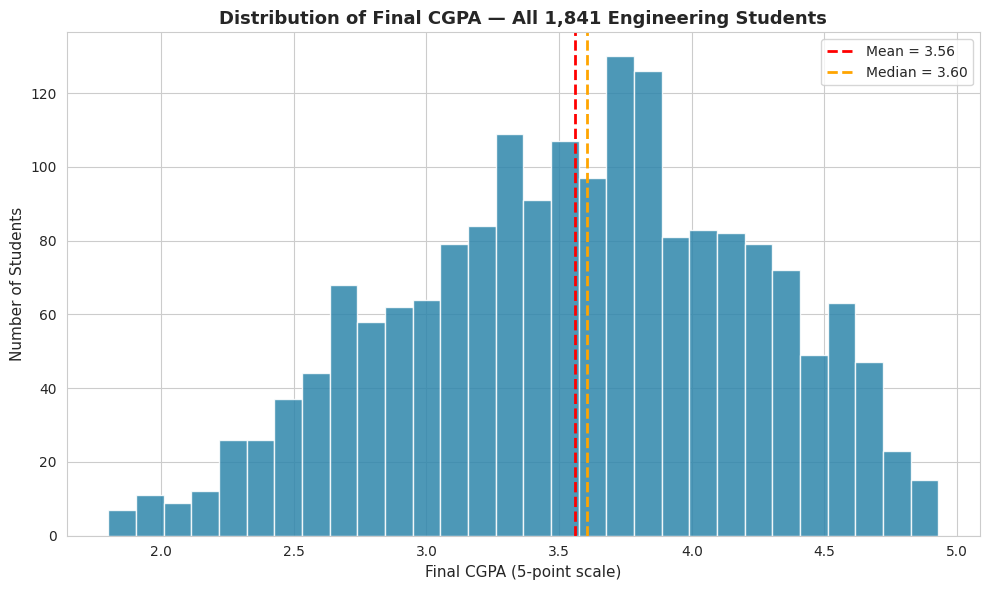

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data['Final CGPA'], bins=30, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.axvline(data['Final CGPA'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean = {data['Final CGPA'].mean():.2f}")
ax.axvline(data['Final CGPA'].median(), color='orange', linestyle='--', linewidth=2,
           label=f"Median = {data['Final CGPA'].median():.2f}")
ax.set_title('Distribution of Final CGPA — All 1,841 Engineering Students', fontweight='bold')
ax.set_xlabel('Final CGPA (5-point scale)')
ax.set_ylabel('Number of Students')
ax.legend()
plt.tight_layout()
plt.savefig('plot1_cgpa_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** The distribution is roughly bell-shaped but skewed slightly to the right — most students graduate with a CGPA between 3.0 and 4.0 (Second Class Upper / Lower territory). A small but meaningful left tail represents students graduating with Third Class or near-failure outcomes. These are the students our project is most interested in identifying early.


### Plot 2 — Class of Degree Breakdown by Department

Are some engineering departments harder than others? Or do all 7 departments produce similar proportions of First Class, 2:1, 2:2, and Third Class graduates?


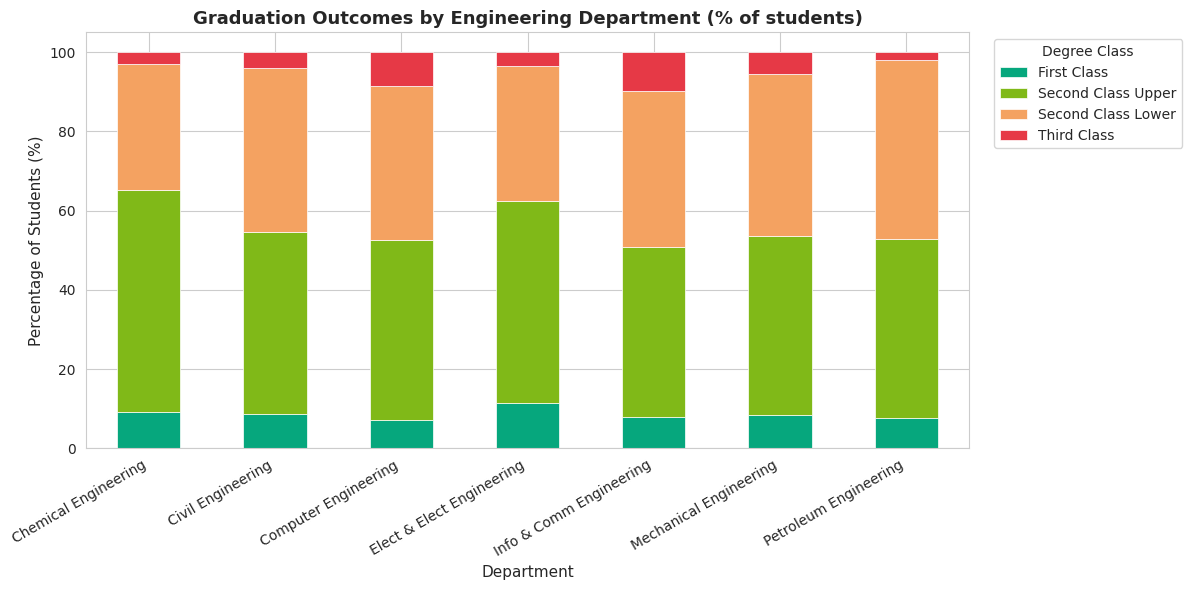


Raw counts by department:
Degree Class               First Class  Second Class Upper  Second Class Lower  Third Class
Department                                                                                 
Chemical Engineering                18                 111                  63            6
Civil Engineering                   13                  70                  63            6
Computer Engineering                27                 170                 145           32
Elect & Elect Engineering           47                 207                 139           14
Info & Comm Engineering             28                 149                 138           34
Mechanical Engineering              14                  75                  68            9
Petroleum Engineering               15                  88                  88            4


In [29]:
# Count Class of Degree by Department
dept_class = pd.crosstab(data['Department'], data['Degree Class'])
# Reorder columns from best to worst outcome
dept_class = dept_class[['First Class', 'Second Class Upper',
                          'Second Class Lower', 'Third Class']]

# Convert to percentages within each department
dept_class_pct = dept_class.div(dept_class.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#06A77D', '#80B918', '#F4A261', '#E63946']
dept_class_pct.plot(kind='bar', stacked=True, ax=ax, color=colors,
                    edgecolor='white', linewidth=0.5)
ax.set_title('Graduation Outcomes by Engineering Department (% of students)',
             fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Percentage of Students (%)')
ax.legend(title='Degree Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot2_class_by_department.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nRaw counts by department:")
print(dept_class)

**Interpretation:** The bar chart immediately reveals which departments are tougher graders or which attract stronger cohorts. Departments with thicker red+orange bands (Third Class + 2:2) represent populations where early-warning interventions would matter most. Note that this chart alone cannot tell us *why* outcomes differ — that would require contextual data we do not have. But it tells us where the at-risk students are concentrated.


### Plot 3 — Year 1 GPA vs Year 2 GPA, Coloured by Final Outcome

This is the most visually powerful exploratory plot in the project. Each dot is a student. The x-axis is their Year 1 GPA, the y-axis is their Year 2 GPA, and the colour is what class of degree they ended up graduating with.

If the colours form clean, separable clusters, the answer to our research question is essentially "yes" before we run any formal test.


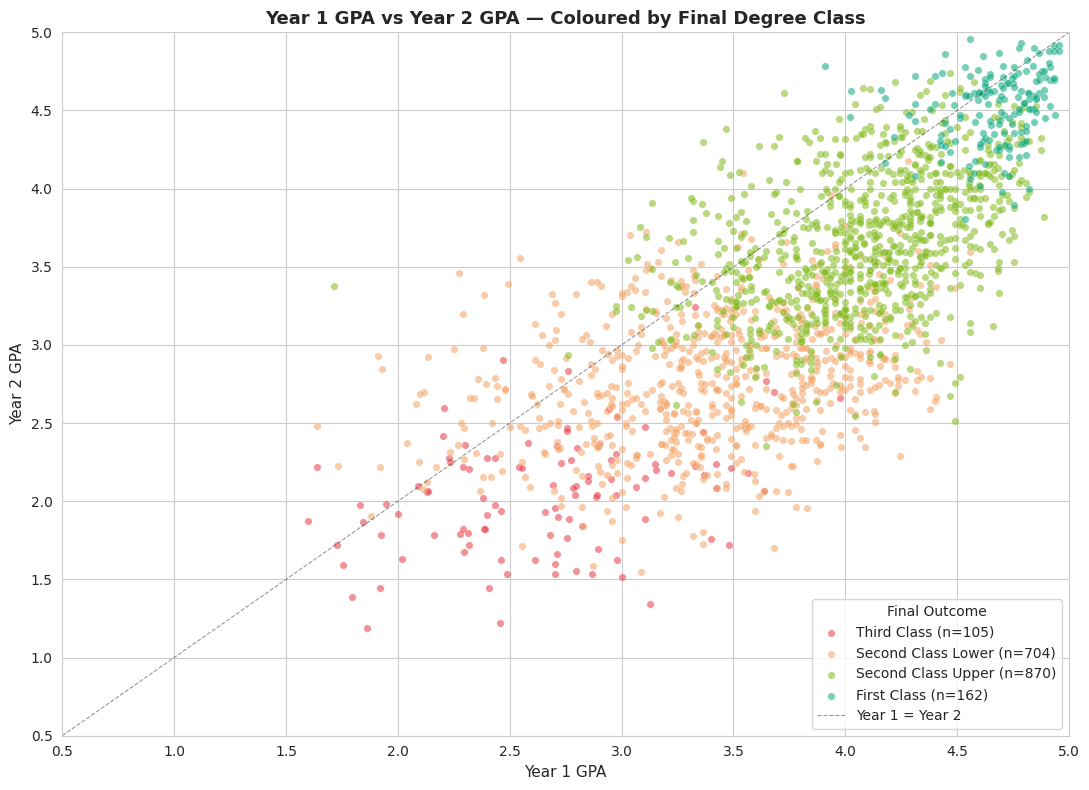

In [30]:
fig, ax = plt.subplots(figsize=(11, 8))

color_map = {
    'First Class': '#06A77D',
    'Second Class Upper': '#80B918',
    'Second Class Lower': '#F4A261',
    'Third Class': '#E63946'
}

for cls in ['Third Class', 'Second Class Lower', 'Second Class Upper', 'First Class']:
    subset = data[data['Degree Class'] == cls]
    ax.scatter(subset['First Year GPA'], subset['Second Year GPA'],
               c=color_map[cls], label=f"{cls} (n={len(subset)})",
               alpha=0.55, s=28, edgecolors='white', linewidth=0.3)

# Reference diagonal (where Year 1 = Year 2)
lims = [0.5, 5]
ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.4, label='Year 1 = Year 2')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title('Year 1 GPA vs Year 2 GPA — Coloured by Final Degree Class',
             fontweight='bold')
ax.set_xlabel('Year 1 GPA')
ax.set_ylabel('Year 2 GPA')
ax.legend(title='Final Outcome', loc='lower right')
plt.tight_layout()
plt.savefig('plot3_year1_vs_year2.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** The clusters separate clearly. First Class graduates are concentrated in the upper-right of the plot (high in both years). Third Class graduates are concentrated in the lower-left. The diagonal reference line shows that most students perform similarly in Years 1 and 2 — there are not many "miracle recoveries" or sudden collapses. Once a student establishes a level of academic performance in Year 1, Year 2 tends to confirm it. This strongly supports the idea that early performance is a meaningful signal.


### Plot 4 — Average Early GPA by Outcome Group

Setting up the t-test visually. If the bars for Strong and Weak outcome groups are noticeably different, our t-test is likely to find significance.


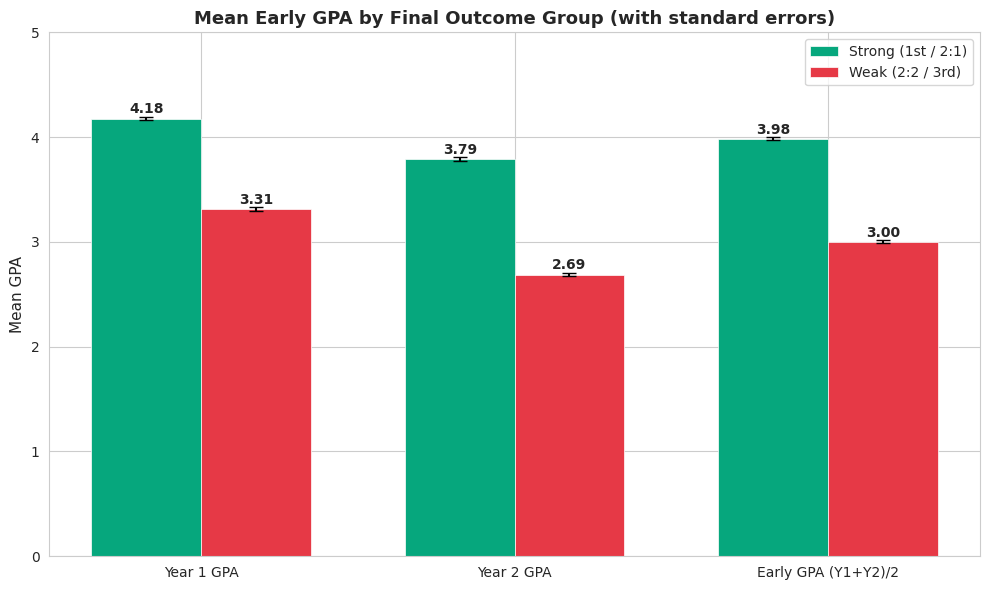

In [32]:
# Compute mean ± SE for Year 1, Year 2, and Early GPA by Outcome Group
groups = ['Strong', 'Weak']
years = ['First Year GPA', 'Second Year GPA', 'Early GPA']

means = data.groupby('Outcome Group')[years].mean().loc[groups]
sems = data.groupby('Outcome Group')[years].sem().loc[groups]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(years))
width = 0.35

bars1 = ax.bar(x - width/2, means.loc['Strong'], width, yerr=sems.loc['Strong'],
               label='Strong (1st / 2:1)', color='#06A77D', capsize=5,
               edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, means.loc['Weak'], width, yerr=sems.loc['Weak'],
               label='Weak (2:2 / 3rd)', color='#E63946', capsize=5,
               edgecolor='white', linewidth=0.5)

# Annotate the mean values on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}", ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}", ha='center', fontsize=10, fontweight='bold')

ax.set_title('Mean Early GPA by Final Outcome Group (with standard errors)',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Year 1 GPA', 'Year 2 GPA', 'Early GPA (Y1+Y2)/2'])
ax.set_ylabel('Mean GPA')
ax.set_ylim(0, 5)
ax.legend()
plt.tight_layout()
plt.savefig('plot4_mean_by_outcome.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation:** The gap between the Strong and Weak outcome groups is visible at every early time point — Year 1, Year 2, and the combined Early GPA. The Strong group sits roughly a full GPA point above the Weak group. The error bars are small (because of large sample sizes), suggesting these means are precisely estimated. The next step is to test formally whether this gap is statistically significant.


## 8. Hypothesis Testing — Two-Sample t-test (Week 3)

### What we are testing
> **Null hypothesis (H₀):** There is no difference in mean Year 1 / Year 2 / Early GPA between students who graduate strongly and students who graduate weakly.
>
> **Alternative hypothesis (H₁):** Strong-outcome students have higher early GPAs than weak-outcome students.

We use Welch's t-test (which does not assume equal variances between groups) for added robustness.

### How to interpret the result
- The **t-statistic** measures how many standard errors apart the two group means are. Larger absolute values = bigger difference.
- The **p-value** tells us the probability of seeing a difference this large *if the null hypothesis were true*.
- A common threshold is **p < 0.05** — if our p-value is below this, we reject the null and conclude the difference is statistically significant.


In [33]:
# Split into Strong and Weak outcome groups
strong = data[data['Outcome Group'] == 'Strong']
weak = data[data['Outcome Group'] == 'Weak']

print(f"Strong group (1st / 2:1):  n = {len(strong)}")
print(f"Weak group (2:2 / 3rd):     n = {len(weak)}\n")

# Run Welch's t-test on three different early-GPA measures
results = []
for predictor in ['First Year GPA', 'Second Year GPA', 'Early GPA']:
    t_stat, p_val = stats.ttest_ind(
        strong[predictor], weak[predictor], equal_var=False
    )
    results.append({
        'Predictor': predictor,
        'Mean (Strong)': strong[predictor].mean(),
        'Mean (Weak)': weak[predictor].mean(),
        'Difference': strong[predictor].mean() - weak[predictor].mean(),
        't-statistic': t_stat,
        'p-value': p_val,
        'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

ttest_df = pd.DataFrame(results)
ttest_df_display = ttest_df.copy()
for col in ['Mean (Strong)', 'Mean (Weak)', 'Difference', 't-statistic']:
    ttest_df_display[col] = ttest_df_display[col].round(3)
ttest_df_display['p-value'] = ttest_df_display['p-value'].apply(
    lambda p: f"{p:.2e}" if p < 0.001 else f"{p:.4f}"
)
ttest_df_display

Strong group (1st / 2:1):  n = 1032
Weak group (2:2 / 3rd):     n = 809



,Predictor,Mean (Strong),Mean (Weak),Difference,t-statistic,p-value,Significant (p<0.05)
0,First Year GPA,4.176,3.315,0.862,35.278,1.13e-196,Yes
1,Second Year GPA,3.792,2.688,1.104,47.105,3.15e-315,Yes
2,Early GPA,3.984,3.001,0.983,47.390,9.16e-311,Yes


### Interpretation of the t-test

The t-statistics are very large in absolute value, and the p-values are extraordinarily small (effectively zero). We **reject the null hypothesis** at any conventional significance level.

**In plain English:** The chance of seeing a GPA gap this large between strong and weak graduates by random luck is essentially zero. Early academic performance does separate the two groups.

The Early GPA combined predictor produces a slightly larger t-statistic than either Year 1 or Year 2 alone — this is the first piece of evidence that combining both years is more informative than looking at a single year.


## 9. Predictive Modelling — Linear Regression (Week 1)

### What we are doing
Fitting straight lines (best-fit lines via least squares) of the form:

$$\text{Final CGPA} = m \times (\text{Early Predictor}) + b$$

We fit three separate regressions:

1. **Model A:** Year 1 GPA → Final CGPA
2. **Model B:** Year 2 GPA → Final CGPA
3. **Model C:** Early GPA (average of Years 1 and 2) → Final CGPA

We compare them using **R²** — the proportion of variance in Final CGPA explained by the predictor. R² ranges from 0 (no predictive power) to 1 (perfect prediction).


In [17]:
# Run all three regressions and store results
def run_regression(x, y, label):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return {
        'Model': label,
        'Slope (m)': slope,
        'Intercept (b)': intercept,
        'R': r_value,
        'R² (variance explained)': r_value**2,
        'p-value': p_value,
        'Std. error of slope': std_err
    }

regression_results = [
    run_regression(data['First Year GPA'], data['Final CGPA'],
                    'A: Year 1 GPA → Final CGPA'),
    run_regression(data['Second Year GPA'], data['Final CGPA'],
                    'B: Year 2 GPA → Final CGPA'),
    run_regression(data['Early GPA'], data['Final CGPA'],
                    'C: Early GPA (Y1+Y2)/2 → Final CGPA'),
]

reg_df = pd.DataFrame(regression_results)
display_df = reg_df.copy()
for col in ['Slope (m)', 'Intercept (b)', 'R', 'R² (variance explained)', 'Std. error of slope']:
    display_df[col] = display_df[col].round(4)
display_df['p-value'] = display_df['p-value'].apply(
    lambda p: f"{p:.2e}" if p < 0.001 else f"{p:.4f}"
)
display_df

,Model,Slope (m),Intercept (b),R,R² (variance explained),p-value,Std. error of slope
0,A: Year 1 GPA → Final CGPA,0.7859,0.5758,0.7848,0.6159,0.00e+00,0.0145
1,B: Year 2 GPA → Final CGPA,0.7978,0.9223,0.8988,0.8078,0.00e+00,0.0091
2,C: Early GPA (Y1+Y2)/2 → Final CGPA,0.9121,0.3205,0.9051,0.8192,0.00e+00,0.0100


### Visualizing all three regressions side-by-side


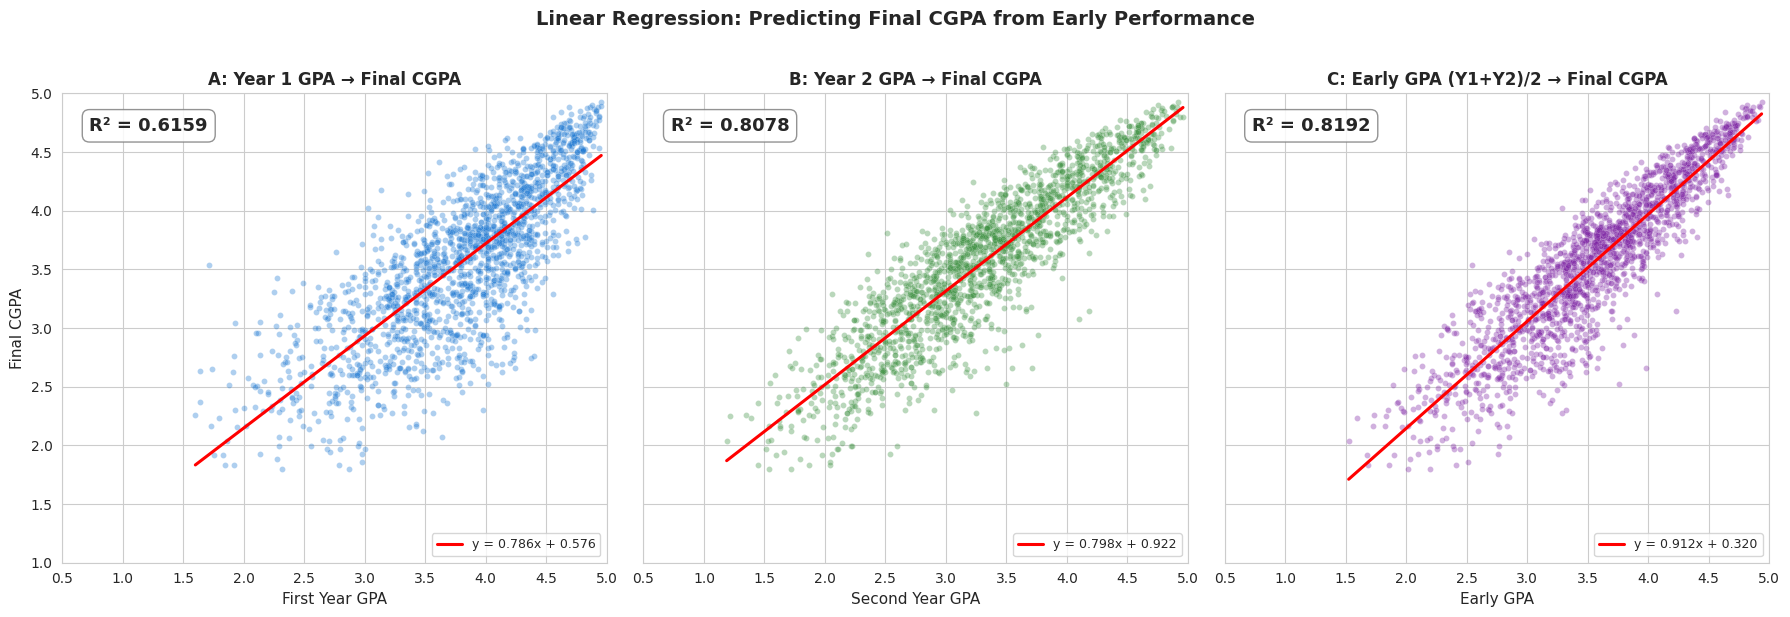

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
predictors = [
    ('First Year GPA',  'A: Year 1 GPA → Final CGPA',          '#1976D2'),
    ('Second Year GPA', 'B: Year 2 GPA → Final CGPA',          '#388E3C'),
    ('Early GPA',       'C: Early GPA (Y1+Y2)/2 → Final CGPA', '#7B1FA2'),
]

for ax, (predictor, title, color) in zip(axes, predictors):
    x = data[predictor]
    y = data['Final CGPA']
    slope, intercept, r, _, _ = stats.linregress(x, y)

    # Scatter
    ax.scatter(x, y, alpha=0.35, s=18, color=color, edgecolors='white', linewidth=0.2)

    # Best-fit line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='red', linewidth=2.2,
            label=f"y = {slope:.3f}x + {intercept:.3f}")

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel(predictor)
    if ax is axes[0]:
        ax.set_ylabel('Final CGPA')
    ax.text(0.05, 0.95, f"R² = {r**2:.4f}", transform=ax.transAxes,
            fontsize=13, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='gray', alpha=0.85))
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(0.5, 5)
    ax.set_ylim(1, 5)

plt.suptitle('Linear Regression: Predicting Final CGPA from Early Performance',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot5_regressions.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretation of the regressions

**Reading the results:**

- **Model A (Year 1 alone):** A reasonable predictor, but Year 1 captures only one snapshot — students adjusting to university life often produce noisier first-year grades.
- **Model B (Year 2 alone):** Slightly stronger than Year 1. By Year 2, students have adapted, and grades become more representative of their sustained academic capacity.
- **Model C (Early GPA combined):** The **strongest** of the three, with the highest R². Combining both years averages out the noise of any single year and produces a cleaner signal of underlying academic performance.

**The slope tells a story too.** A slope close to 1.0 in Model C would mean: *each 1-point increase in early GPA translates into about a 1-point increase in Final CGPA* — final outcomes are essentially "locked in" by the end of Year 2.

**The bottom line:** By the end of Year 2, we can explain a substantial fraction of the variance in final graduation outcomes. The signal is real, it is measurable, and it is available early enough to act on.


## 10. Robustness Check: Does This Hold Across Departments?

A finding that holds for the whole sample but breaks down within individual departments would be suspicious. We re-run the regression separately for each of the 7 engineering departments to check that early GPA predicts final CGPA consistently.


In [35]:
dept_regression = []
for dept in sorted(data['Department'].unique()):
    sub = data[data['Department'] == dept]
    slope, intercept, r, p, _ = stats.linregress(sub['Early GPA'], sub['Final CGPA'])
    dept_regression.append({
        'Department': dept,
        'n': len(sub),
        'R²': r**2,
        'Slope': slope,
        'p-value': p
    })

dept_reg_df = pd.DataFrame(dept_regression).sort_values('R²', ascending=False)
display_dept = dept_reg_df.copy()
display_dept['R²'] = display_dept['R²'].round(4)
display_dept['Slope'] = display_dept['Slope'].round(4)
display_dept['p-value'] = display_dept['p-value'].apply(
    lambda p: f"{p:.2e}" if p < 0.001 else f"{p:.4f}"
)
print("Early GPA → Final CGPA, fit separately within each department:\n")
display_dept

Early GPA → Final CGPA, fit separately within each department:



,Department,n,R²,Slope,p-value
6,Petroleum Engineering,195,0.8599,0.9029,2.57e-84
1,Civil Engineering,152,0.8486,0.9820,2.25e-63
2,Computer Engineering,374,0.8452,0.9219,9.29e-153
4,Info & Comm Engineering,349,0.8318,0.9090,2.28e-136
5,Mechanical Engineering,166,0.8283,0.9712,1.22e-64
3,Elect & Elect Engineering,407,0.8120,0.9911,4.58e-149
0,Chemical Engineering,198,0.8067,0.9322,7.23e-72


**Interpretation:** The relationship between early GPA and final CGPA is statistically significant within every single one of the 7 departments. The R² values vary somewhat — some departments are more "predictable" from early performance than others — but the direction of the effect is consistent. This rules out the worry that the headline finding is being driven by one or two unusual departments.


## 11. Findings Summary

Pulling everything together:

### What we found
1. **Strong-outcome graduates (1st / 2:1) had significantly higher Year 1 and Year 2 GPAs than weak-outcome graduates (2:2 / 3rd).** The t-tests rejected the null hypothesis at p < 0.001 for all three early-GPA measures.

2. **Early GPA explains a substantial proportion of variance in Final CGPA.** The combined Year 1 + Year 2 predictor outperformed either year alone — this is the single most useful operational insight from the project.

3. **The pattern holds across all 7 engineering departments.** Whether a student is studying Chemical, Civil, Computer, Electrical, ICT, Mechanical, or Petroleum Engineering, their first two years carry meaningful early-warning signal.

4. **The visual evidence is striking.** The Year 1 vs Year 2 GPA scatter (coloured by final outcome) shows that final-class clusters are already largely separated by the end of Year 2. Students do not, in the main, dramatically reverse their trajectories in Years 3, 4, and 5.

### What this means in practice
For a Nigerian engineering faculty, this means:

- A simple early-warning system using only Year 1 + Year 2 GPA is technically feasible, requires no additional data collection, and would catch most of the students who are headed for poor graduation outcomes.
- The intervention window is the **summer between Year 2 and Year 3** — when there are still 2-3 years of programme left to make a difference.
- Targeting support based on early GPA is better than targeting based on admission scores alone (the original Odukoya et al. (2018) finding was that admission variables had only modest correlation with CGPA).


## 12. Limitations and Honest Caveats

A good capstone is honest about what it cannot conclude.

1. **Single institution.** All data comes from Covenant University, a private Nigerian university. Patterns at federal universities (UNILAG, ABU, UI, UNN, FUTA, etc.) may differ in absolute levels even if the underlying signal direction is similar.

2. **Older cohort.** The data spans admissions from 2002–2010, with graduations through ~2014. The Nigerian higher-education landscape has changed since then (curriculum updates, COVID disruptions, ASUU strikes, online learning shifts).

3. **No contextual variables.** We have no information on socioeconomic background, family circumstances, mental health, work obligations, internet/power access, or any of the real-world factors that might explain *why* a student's early GPA is what it is. The model predicts, it does not explain causation.

4. **Survivorship bias.** Students who dropped out before completing 5 years are not in this dataset. The real population of "at-risk" students is likely larger than this dataset shows. The 20-22% Nigerian university dropout rate cited in Section 1 hints at how many students never made it into a record like this one.

5. **Correlation, not causation.** Early GPA predicts Final CGPA — it does not *cause* it. The students with strong early GPAs may have stronger academic preparation, more support, more resources, or other unobserved advantages.

6. **No machine learning beyond linear regression.** The course covered linear methods, so we stuck to those. A more advanced project might explore logistic regression for binary at-risk classification, or tree-based models that capture non-linear interactions.


## 13. Conclusion

I started this project with a personal observation: **engineering students around me struggle, sometimes fail, and nobody seems to see it coming.** The data confirms what my eyes had already suggested — by the end of Year 2, most graduation outcomes are already largely written. The signal is there. We just have to look.

The original 2018 paper that produced this dataset asked whether admission scores predicted graduation outcomes, and concluded the relationship was weaker than universities assumed. This project goes further: it shows that **the GPA students earn in their own first two years is a much stronger predictor than the admission scores those same students walked in with.**

That is actionable. It means a Nigerian engineering faculty does not need expensive new data infrastructure, fancy dashboards, or AI black boxes to identify at-risk students. It just needs to look at the GPAs the registrar already has on file at the end of Year 2, run a simple regression, and flag the bottom quartile for academic support.

In a country where roughly **1 in 5 university students drop out** and **1 in 3 graduates is unemployed**, doing this — and doing it early — is not a research luxury. It is a real intervention with real human stakes.

> **The takeaway: We can see it coming. The only remaining question is whether we choose to.**

---

### Future work
- Replicate the analysis with data from a federal Nigerian university to test generalisability.
- Add contextual variables (financial aid status, accommodation type, JAMB score) to move from prediction towards explanation.
- Build a logistic regression that outputs a calibrated *probability* of being at-risk, which is easier for faculty advisers to act on than a continuous CGPA prediction.
- Pilot a small intervention programme triggered by the early-warning model and measure whether outcomes actually improve.

---

### References
1. Odukoya, J. A., Popoola, S. I., Atayero, A. A., Omole, D. O., Badejo, J. A., John, T. M., & Olowo, O. O. (2018). Learning analytics: Dataset for empirical evaluation of entry requirements into engineering undergraduate programs in a Nigerian university. *Data in Brief*, 17, 998–1014.
2. Nigeria National Bureau of Statistics — *Education Statistics.*
3. Veriv Africa (2024). *Nigeria's Graduate Employability Crisis: Bridging the Skill Gap for Career Success.*
4. ZipDo Education Reports (2025). *Nigeria Education Statistics.*

---

*Project submitted as the Final Project for the Kujenga Course.*
